In [130]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from tqdm.auto import tqdm

/Users/kuroyami/Desktop/NeuralNetworks/MachineLearning/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [91]:
frame = load_diabetes(as_frame = True).frame

In [92]:
frame.shape

(442, 11)

In [93]:
frame.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [94]:
X, y = load_diabetes(return_X_y = True)

In [95]:
X

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]], shape=(442, 10))

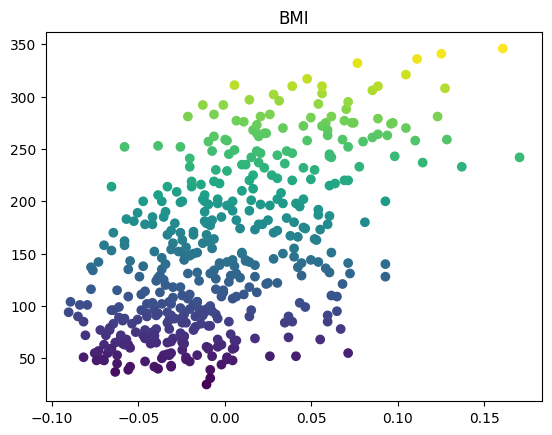

In [96]:
plt.scatter(frame["bmi"], frame["target"], c=y)
plt.title("BMI")
# plt.legend()
plt.show()

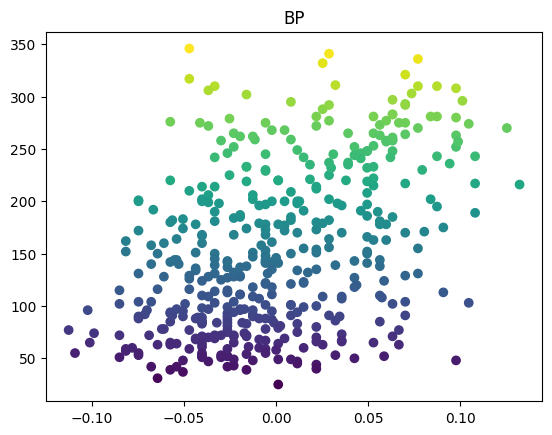

In [97]:
plt.scatter(frame["bp"], frame["target"], c=y)
plt.title("BP")
plt.show()

In [98]:
y[:5]

array([151.,  75., 141., 206., 135.])

<Axes: >

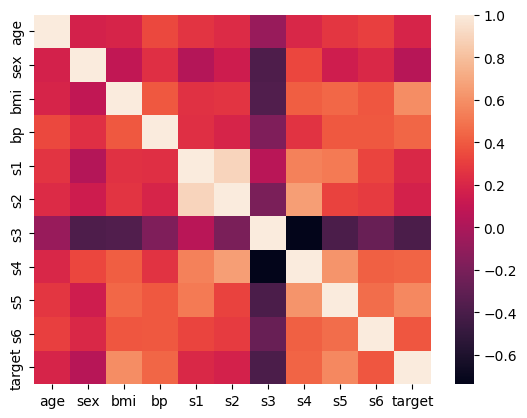

In [99]:
sns.heatmap(frame.corr())

In [100]:
X_tensor = torch.tensor(X, dtype = torch.float32)
y_tensor = torch.tensor(y, dtype = torch.float32)

In [101]:
X_tensor[:2], y_tensor[:2]

(tensor([[ 0.0381,  0.0507,  0.0617,  0.0219, -0.0442, -0.0348, -0.0434, -0.0026,
           0.0199, -0.0176],
         [-0.0019, -0.0446, -0.0515, -0.0263, -0.0084, -0.0192,  0.0744, -0.0395,
          -0.0683, -0.0922]]),
 tensor([151.,  75.]))

In [102]:
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size = 0.2, shuffle = True, random_state = 42)

In [103]:
len(X_train), len(X_test), len(y_train), len(y_test)

(353, 89, 353, 89)

tensor([219.,  70., 202., 230., 111.,  84., 242., 272.,  94.,  96.,  94., 252.,
         99., 297., 135.,  67., 295., 264., 170., 275., 310.,  64., 128., 232.,
        129., 118., 263.,  77.,  48., 107., 140., 113.,  90., 164., 180., 233.,
         42.,  84., 172.,  63.,  48., 108., 156., 168.,  90.,  52., 200.,  87.,
         90., 258., 136., 158.,  69.,  72., 171.,  95.,  72., 151., 168.,  60.,
        122.,  52., 187., 102., 214., 248., 181., 110., 140., 202., 101., 222.,
        281.,  61.,  89.,  91., 186., 220., 237., 233.,  68., 190.,  96.,  72.,
        153.,  98.,  37.,  63., 184.])

In [107]:
class DiabetesModel(torch.nn.Module):
    def __init__(self, in_features: int = 10, out_features: int = 10, hidden_units: int = 10):
        super(DiabetesModel, self).__init__()
    
        self.in_features: int = in_features
        self.out_features: int = out_features
        self.hidden_units: int = hidden_units
    
        self.network: torch.nn.Sequential = torch.nn.Sequential(
            torch.nn.Linear(in_features = self.in_features,
                           out_features = self.hidden_units),
            torch.nn.Linear(in_features = self.hidden_units,
                           out_features = self.hidden_units),
            torch.nn.Linear(in_features = self.hidden_units,
                           out_features = self.out_features)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x

In [113]:
device = "mps" if torch.mps.is_available() else "cpu"
device

'mps'

In [114]:
model = DiabetesModel(in_features = X_train.shape[1], out_features = 1).to(device)
model

DiabetesModel(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=10, bias=True)
    (1): Linear(in_features=10, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=1, bias=True)
  )
)

In [119]:
model.eval()

with torch.inference_mode():
    y_pred = model(X_test.to(device))
    
y_pred[:5], y_train[:5]

(tensor([[0.2064],
         [0.2009],
         [0.2046],
         [0.1966],
         [0.2085]], device='mps:0'),
 tensor([144., 150., 280., 125.,  59.]))

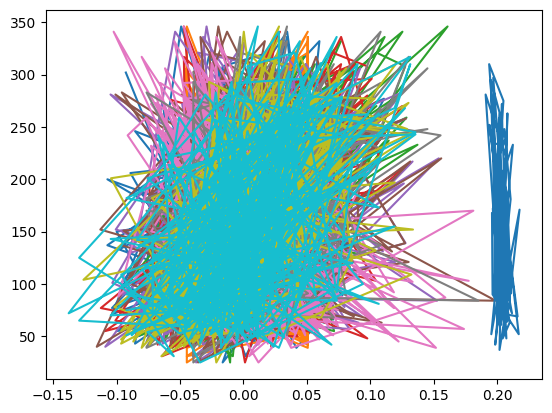

In [126]:
plt.plot(X_train.detach().cpu(), y_train.detach().cpu())
plt.plot(y_pred.squeeze().detach().cpu(), y_test.detach().cpu())

In [128]:
criterion = torch.nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3, weight_decay = 1e-4)

In [136]:
epochs = 10

total_epochs, losses, test_losses = [], [], []
train_r2_scores, test_r2_scores = [], []

for epoch in tqdm(range(epochs)):
    model.train()

    y_pred = model(X_train.to(device))
    loss = criterion(y_pred, y_train.to(device))
    optimizer.zero_grad()

    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    train_r2 = r2_score(y_train, y_pred.detach().cpu())
    train_r2_scores.append(train_r2)

    model.eval()
    with torch.inference_mode():
        y_test_pred = model(X_test.to(device))
        test_loss = criterion(y_test_pred, y_test.to(device))

        test_r2 = r2_score(y_test, y_test_pred.detach().cpu())
        test_losses.append(test_loss.item())
        test_r2_scores.append(test_r2)

    total_epochs.append(epoch)

    if epoch % (0.1 * epochs) == 0:
        print(f"Training loss: {loss}, Testing loss: {test_loss}")
        print(f"Training R2: {train_r2} | Testing R2: {test_r2}")

  0%|                                                    | 0/10 [00:00<?, ?it/s]/Users/kuroyami/Desktop/NeuralNetworks/MachineLearning/.venv/lib/python3.13/site-packages/torch/nn/modules/loss.py:132: UserWarning: Using a target size (torch.Size([353])) that is different to the input size (torch.Size([353, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)
/Users/kuroyami/Desktop/NeuralNetworks/MachineLearning/.venv/lib/python3.13/site-packages/torch/nn/modules/loss.py:132: UserWarning: Using a target size (torch.Size([89])) that is different to the input size (torch.Size([89, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)
/Users/kuroyami/Desktop/NeuralNetworks/MachineLearning/.venv/lib/python3.13/site-packages/torch/nn/modules/loss.py:132: UserWarnin

Training loss: 153.48654174804688, Testing loss: 145.51475524902344
Training R2: -3.8770298957824707 | Testing R2: -3.996631622314453
Training loss: 153.4770050048828, Testing loss: 145.5052490234375
Training R2: -3.8765478134155273 | Testing R2: -3.9961094856262207
Training loss: 153.46749877929688, Testing loss: 145.4957733154297
Training R2: -3.8760647773742676 | Testing R2: -3.9955878257751465
Training loss: 153.45797729492188, Testing loss: 145.4862823486328
Training R2: -3.875581741333008 | Testing R2: -3.995065689086914
Training loss: 153.4484405517578, Testing loss: 145.47679138183594
Training R2: -3.8750991821289062 | Testing R2: -3.99454402923584
Training loss: 153.43890380859375, Testing loss: 145.46731567382812
Training R2: -3.8746156692504883 | Testing R2: -3.9940223693847656
Training loss: 153.42938232421875, Testing loss: 145.45782470703125
Training R2: -3.8741326332092285 | Testing R2: -3.993500232696533
Training loss: 153.4198455810547, Testing loss: 145.44833374023438